In [1]:
karate club graph()

SyntaxError: invalid syntax (3761370028.py, line 1)

In [3]:
import networkx as nx
import random

def random_walk(graph, start_node, walk_length):
    """
    Simulates a random walk on the given graph.
    
    Parameters:
        graph (nx.Graph): The graph to walk on.
        start_node (int): The starting node.
        walk_length (int): The number of steps in the walk.
    
    Returns:
        list: A sequence of visited nodes.
    """
    walk = [start_node]
    current_node = start_node

    for _ in range(walk_length - 1):
        neighbors = list(graph.neighbors(current_node))
        if not neighbors:
            break  # Stop if there are no neighbors (isolated node)
        current_node = random.choice(neighbors)
        walk.append(current_node)

    return walk


# --- Example usage ---
# Load the Karate Club graph
G = nx.karate_club_graph()

# Set parameters
start = 0         # starting node
steps = 20        # number of steps

# Run the random walk
path = random_walk(G, start, steps)

print("Random walk sequence:", path)


Random walk sequence: [0, 1, 17, 1, 7, 1, 7, 1, 3, 0, 21, 1, 19, 33, 23, 25, 24, 27, 24, 25]


    node  degree  mix_time_ε=0.1  mix_time_ε=0.01  mix_time_ε=0.001  \
0      0    16.0              10               26                43   
1      1     9.0               8               22                38   
2      2    10.0               5               11                19   
3      3     6.0               9               23                39   
4      4     3.0              15               32                48   
5      5     4.0              16               32                49   
6      6     4.0              16               32                49   
7      7     4.0               8               23                39   
8      8     5.0               5               18                35   
9      9     2.0               7               22                38   
10    10     3.0              15               32                48   
11    11     1.0              11               27                44   
12    12     2.0              10               26                42   
13    

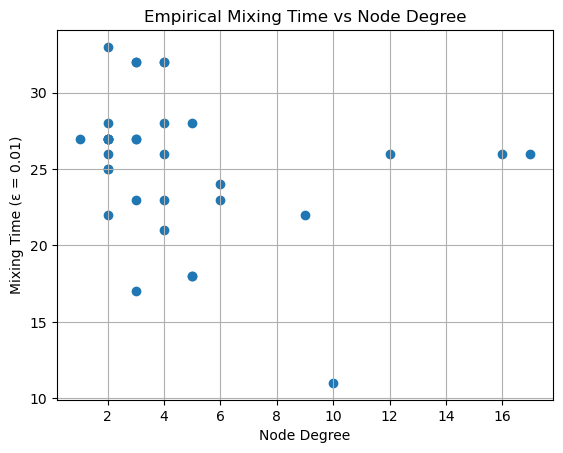

In [5]:
import networkx as nx
import numpy as np
import random

# Load the classic Zachary Karate Club graph
G = nx.karate_club_graph()
n = G.number_of_nodes()
nodes = list(G.nodes())
# Build a transition matrix P (n x n)
P = np.zeros((n, n))
for i in nodes:
    neighbors = list(G.neighbors(i))
    if neighbors:
        for j in neighbors:
            P[i, j] = 1 / len(neighbors)
degrees = np.array([G.degree(i) for i in nodes], dtype=float)
pi = degrees / degrees.sum()

def variation_distance(p, q):
    return 0.5 * np.sum(np.abs(p - q))
epsilons = [0.1, 0.01, 0.001, 0.0001]
max_steps = 500

mixing_times = {eps: [] for eps in epsilons}

for start_node in nodes:
    p = np.zeros(n)
    p[start_node] = 1
    found = {eps: None for eps in epsilons}

    for t in range(1, max_steps + 1):
        p = p @ P  # one-step evolution

        for eps in epsilons:
            if found[eps] is None and variation_distance(p, pi) <= eps:
                found[eps] = t

        # Stop early if all eps reached
        if all(found[eps] is not None for eps in epsilons):
            break

    for eps in epsilons:
        mixing_times[eps].append(found[eps])

import pandas as pd

df = pd.DataFrame({
    'node': nodes,
    'degree': degrees,
    **{f'mix_time_ε={eps}': mixing_times[eps] for eps in epsilons}
})

print(df)
import matplotlib.pyplot as plt

plt.scatter(df['degree'], df['mix_time_ε=0.01'])
plt.xlabel('Node Degree')
plt.ylabel('Mixing Time (ε = 0.01)')
plt.title("Empirical Mixing Time vs Node Degree")
plt.grid(True)
plt.show()
